# Salama Health Modelling Phase 1
### XGBoost Baseline → CDI Score Assembly → Facility Risk Ranking

**Input:** `SSD_Training_Dataset_v2.csv` — 9,617 rows, 30 features, 93 facilities

**Output:**
- Trained XGBoost P(flood) model
- CDI scores for all 93 facilities
- Ranked facility risk list

## 0. Setup

In [1]:
!pip install xgboost scikit-learn shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import os
import pickle
import json

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.model_selection import StratifiedKFold
import shap

warnings.filterwarnings('ignore')

DATA_PATH = '/kaggle/input/datasets/mubarakabanadda/ssd-training-data/SSD_Training_Dataset_v2.csv'
OUT_DIR   = '/kaggle/working'

print('Setup complete')

Setup complete


## 1. Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

print(f'Shape:      {df.shape}')
print(f'Facilities: {df["facility_name"].nunique()}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Disrupted:  {df["disrupted"].sum():,} ({df["disrupted"].mean()*100:.2f}%)')
print(f'\nBy state:')
print(df.groupby('state')['disrupted'].agg(['sum','mean'])
      .rename(columns={'sum':'count','mean':'rate'}))

Shape:      (9617, 41)
Facilities: 93
Date range: 2021-01-02 to 2024-12-30
Disrupted:  474 (4.93%)

By state:
            count      rate
state                      
Jonglei       200  0.051138
Unity         236  0.064043
Upper Nile     38  0.018803


## 2. Feature Selection

In [3]:
FEATURE_COLS = [
    # SAR — P(flood)
    'VV_backscatter', 'VV_7day_mean', 'VV_delta', 'flood_signal',
    # Elevation — P(flood), P(cutoff)
    'elevation_m', 'low_elevation',
    # Rainfall — P(flood)
    'chirps_rainfall_mm', 'chirps_anomaly', 'rainfall_roll30d',
    'rainfall_lag7d', 'rainfall_lag14d', 'rainfall_lag28d', 'rainfall_anomaly',
    # Temperature / cold chain — P(CCF)
    'temp_max_celsius', 'temp_min_celsius', 'temp_anomaly',
    'temp_excess_8c', 'ccf_risk', 'cumulative_heat_7d', 'freeze_risk',
    # Humidity
    'humidity_pct',
    # Drought / displacement — P(disp)
    'evapotranspiration', 'water_deficit', 'drought_signal',
    'idp_normalised',
    # Seasonality
    'season_sin', 'season_cos', 'rainy_season', 'month',
]
TARGET = 'disrupted'

# Ensure all numeric
for col in FEATURE_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f'Features: {len(FEATURE_COLS)}')
print(f'Target:   {TARGET}')
print(f'Nulls:    {df[FEATURE_COLS].isnull().sum().sum()}')

Features: 29
Target:   disrupted
Nulls:    0


## 3. Train / Test Split
Time-based split train on 2021–2023, test on 2024.
No data leakage the model never sees future observations during training.

In [4]:
train = df[df['date'].dt.year <= 2023].copy()
test  = df[df['date'].dt.year == 2024].copy()

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

# Class imbalance weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

print(f'Train: {len(train):,} rows | {int(y_train.sum())} disrupted ({y_train.mean()*100:.2f}%)')
print(f'Test:  {len(test):,}  rows | {int(y_test.sum())} disrupted ({y_test.mean()*100:.2f}%)')
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

Train: 7,682 rows | 365 disrupted (4.75%)
Test:  1,935  rows | 109 disrupted (5.63%)
scale_pos_weight: 20.0


## 4. Train XGBoost Model

In [5]:
model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    eval_metric       = 'auc',
    early_stopping_rounds = 20,
    random_state      = 42,
    verbosity         = 0
)

model.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = False
)

print(f'Best iteration: {model.best_iteration}')
print('Model trained')

Best iteration: 3
Model trained


## 5. Evaluate Model Performance

In [6]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = model.predict(X_test)

auc       = roc_auc_score(y_test, y_proba)
f1        = f1_score(y_test, y_pred, zero_division=0)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)

print('── Model Performance ────────────────────────────────────')
print(f'AUC-ROC:   {auc:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'\n{classification_report(y_test, y_pred, zero_division=0)}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(f'  True Negatives:  {cm[0,0]}')
print(f'  False Positives: {cm[0,1]}')
print(f'  False Negatives: {cm[1,0]}')
print(f'  True Positives:  {cm[1,1]}')

── Model Performance ────────────────────────────────────
AUC-ROC:   0.9996
F1 Score:  0.9864
Precision: 0.9732
Recall:    1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1826
           1       0.97      1.00      0.99       109

    accuracy                           1.00      1935
   macro avg       0.99      1.00      0.99      1935
weighted avg       1.00      1.00      1.00      1935

Confusion Matrix:
  True Negatives:  1823
  False Positives: 3
  False Negatives: 0
  True Positives:  109


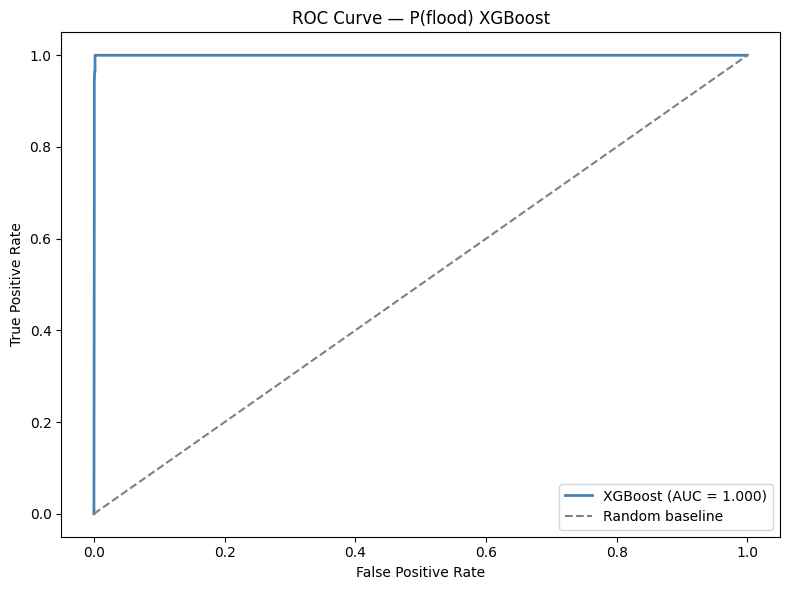

In [7]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], color='grey', linestyle='--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — P(flood) XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/roc_curve.png', dpi=150)
plt.show()

## 6. Feature Importance

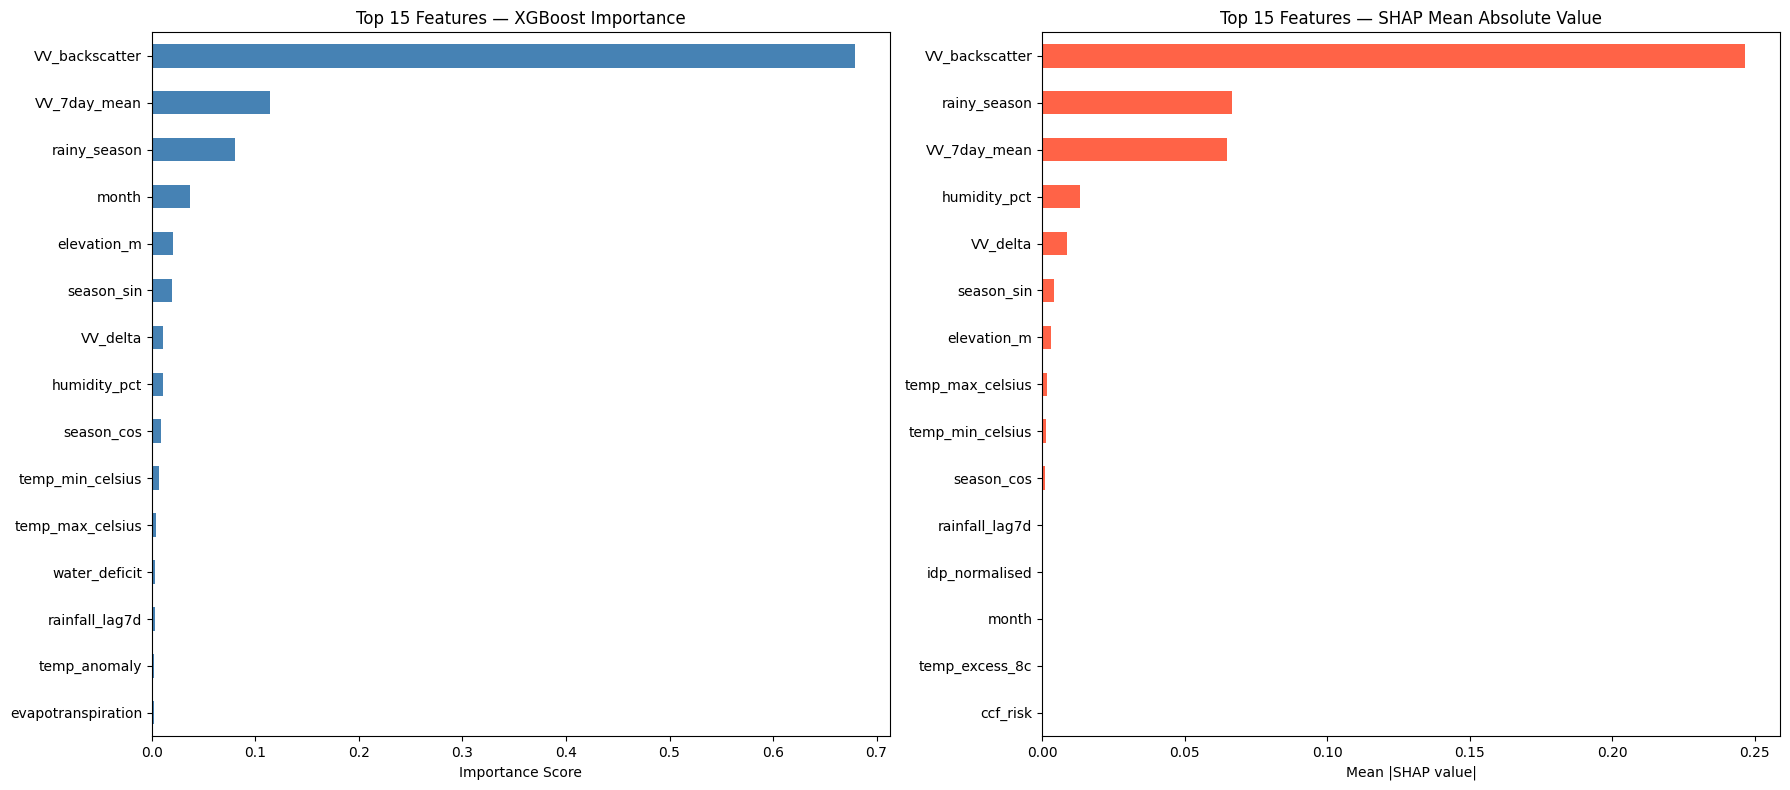

Top 10 features by SHAP:
VV_backscatter      0.2465
rainy_season        0.0666
VV_7day_mean        0.0647
humidity_pct        0.0132
VV_delta            0.0086
season_sin          0.0043
elevation_m         0.0032
temp_max_celsius    0.0016
temp_min_celsius    0.0014
season_cos          0.0011
dtype: float32


In [8]:
# XGBoost built-in importance
importances = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 15 features
importances.tail(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Features — XGBoost Importance')
axes[0].set_xlabel('Importance Score')

# SHAP values
explainer  = shap.TreeExplainer(model)
shap_vals  = explainer.shap_values(X_test)
shap_abs   = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=True)

shap_abs.tail(15).plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Top 15 Features — SHAP Mean Absolute Value')
axes[1].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/feature_importance.png', dpi=150)
plt.show()

print('Top 10 features by SHAP:')
print(shap_abs.tail(10).sort_values(ascending=False).round(4))

## 7. Cross-Validation
5-fold stratified cross-validation for more robust performance estimate.

In [9]:
X_all = df[FEATURE_COLS]
y_all = df[TARGET]

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = []
cv_f1  = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_all, y_all)):
    X_tr, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]

    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    spw = neg / max(pos, 1)

    m = XGBClassifier(
        n_estimators     = 300,
        max_depth        = 5,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = spw,
        eval_metric      = 'auc',
        random_state     = 42,
        verbosity        = 0
    )
    m.fit(X_tr, y_tr, verbose=False)

    proba = m.predict_proba(X_val)[:, 1]
    pred  = m.predict(X_val)

    fold_auc = roc_auc_score(y_val, proba)
    fold_f1  = f1_score(y_val, pred, zero_division=0)
    cv_auc.append(fold_auc)
    cv_f1.append(fold_f1)
    print(f'Fold {fold+1}: AUC={fold_auc:.4f} | F1={fold_f1:.4f}')

print(f'\nMean AUC: {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')
print(f'Mean F1:  {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}')

Fold 1: AUC=1.0000 | F1=0.9845
Fold 2: AUC=0.9999 | F1=0.9948
Fold 3: AUC=1.0000 | F1=0.9895
Fold 4: AUC=1.0000 | F1=1.0000
Fold 5: AUC=1.0000 | F1=0.9896

Mean AUC: 1.0000 ± 0.0000
Mean F1:  0.9917 ± 0.0053


## 8. CDI Score Assembly

**Formula:** `CDI = 0.35 × P(flood) + 0.30 × P(cutoff) + 0.20 × P(CCF) + 0.15 × P(disp)`

| Component | Weight | Method | Status |
|---|---|---|---|
| P(flood)  | 0.35 | XGBoost this model | ✅ Active |
| P(cutoff) | 0.30 | Rule-based: elevation + rainfall | ✅ Active |
| P(CCF)    | 0.20 | Temperature exceedance above 8°C | ✅ Active |
| P(disp)   | 0.15 | IOM DTM normalised IDP count | ✅ Active |

In [10]:
# Use most recent 8 weeks per facility as current state
recent = (
    df.sort_values('date')
    .groupby('facility_name')
    .tail(8)
    .copy()
)

# P(flood) from XGBoost
recent['P_flood'] = model.predict_proba(
    recent[FEATURE_COLS].fillna(0)
)[:, 1]

# P(cutoff) — rule-based
# High rainfall + low elevation = road likely cut off
recent['P_cutoff'] = (
    (recent['low_elevation'] * 0.5) +
    (recent['chirps_rainfall_mm'] / recent['chirps_rainfall_mm'].max() * 0.5)
).clip(0, 1)

# P(CCF) — cold chain failure from temperature exceedance above 8C
recent['P_CCF'] = recent['ccf_risk'].clip(0, 1)

# P(disp) — displacement pressure
recent['P_disp'] = recent['idp_normalised'].clip(0, 1)

# Aggregate to one row per facility
cdi_scores = (
    recent
    .groupby(['facility_name','state','county'])
    .agg(
        P_flood  = ('P_flood',          'mean'),
        P_cutoff = ('P_cutoff',         'mean'),
        P_CCF    = ('P_CCF',            'mean'),
        P_disp   = ('P_disp',           'mean'),
        avg_VV   = ('VV_backscatter',    'mean'),
        avg_rain = ('chirps_rainfall_mm','mean'),
        avg_temp = ('temp_max_celsius',  'mean'),
        elevation= ('elevation_m',       'mean'),
    )
    .reset_index()
)

# Apply CDI formula
cdi_scores['CDI'] = (
    0.35 * cdi_scores['P_flood']  +
    0.30 * cdi_scores['P_cutoff'] +
    0.20 * cdi_scores['P_CCF']    +
    0.15 * cdi_scores['P_disp']
).round(3)

# Risk bands
cdi_scores['risk_level'] = pd.cut(
    cdi_scores['CDI'],
    bins   = [0, 0.20, 0.40, 0.60, 1.01],
    labels = ['Low','Medium','High','Critical'],
    include_lowest=True
)

cdi_scores = cdi_scores.sort_values('CDI', ascending=False).reset_index(drop=True)

print('── Top 15 Highest Risk Facilities ──────────────────────────────────────')
print(cdi_scores[['facility_name','state','county','CDI','risk_level',
                  'P_flood','P_cutoff','P_CCF','P_disp']].head(15).to_string(index=False))

print('\n── Risk Band Distribution ───────────────────────────────────────────────')
print(cdi_scores['risk_level'].value_counts())

print('\n── CDI by State ─────────────────────────────────────────────────────────')
print(cdi_scores.groupby('state')['CDI'].agg(['mean','min','max']).round(3))

── Top 15 Highest Risk Facilities ──────────────────────────────────────
            facility_name      state  county   CDI risk_level  P_flood  P_cutoff    P_CCF   P_disp
               MELUF PHCC Upper Nile   Melut 0.505       High 0.407758  0.500000 0.309601 1.000000
             CARE RUBKONA      Unity Rubkona 0.486       High 0.407657  0.539736 0.305174 0.800978
          NILE GANGAH B-V      Unity Rubkona 0.486       High 0.407657  0.539736 0.305174 0.800978
           KHAL JAAK PHCC      Unity Rubkona 0.486       High 0.407657  0.539736 0.304255 0.800978
              CARE BENTIU      Unity Rubkona 0.486       High 0.407657  0.539736 0.304133 0.800978
           NHIAL DIU PHCC      Unity Rubkona 0.485       High 0.407696  0.539736 0.302949 0.800978
               REANG PHCC      Unity Rubkona 0.485       High 0.407752  0.539736 0.303395 0.800978
                WAAK PHCC      Unity Rubkona 0.485       High 0.407657  0.539736 0.301121 0.800978
                KAKA PHCC Upper Nile

## 9. Visualise CDI Results

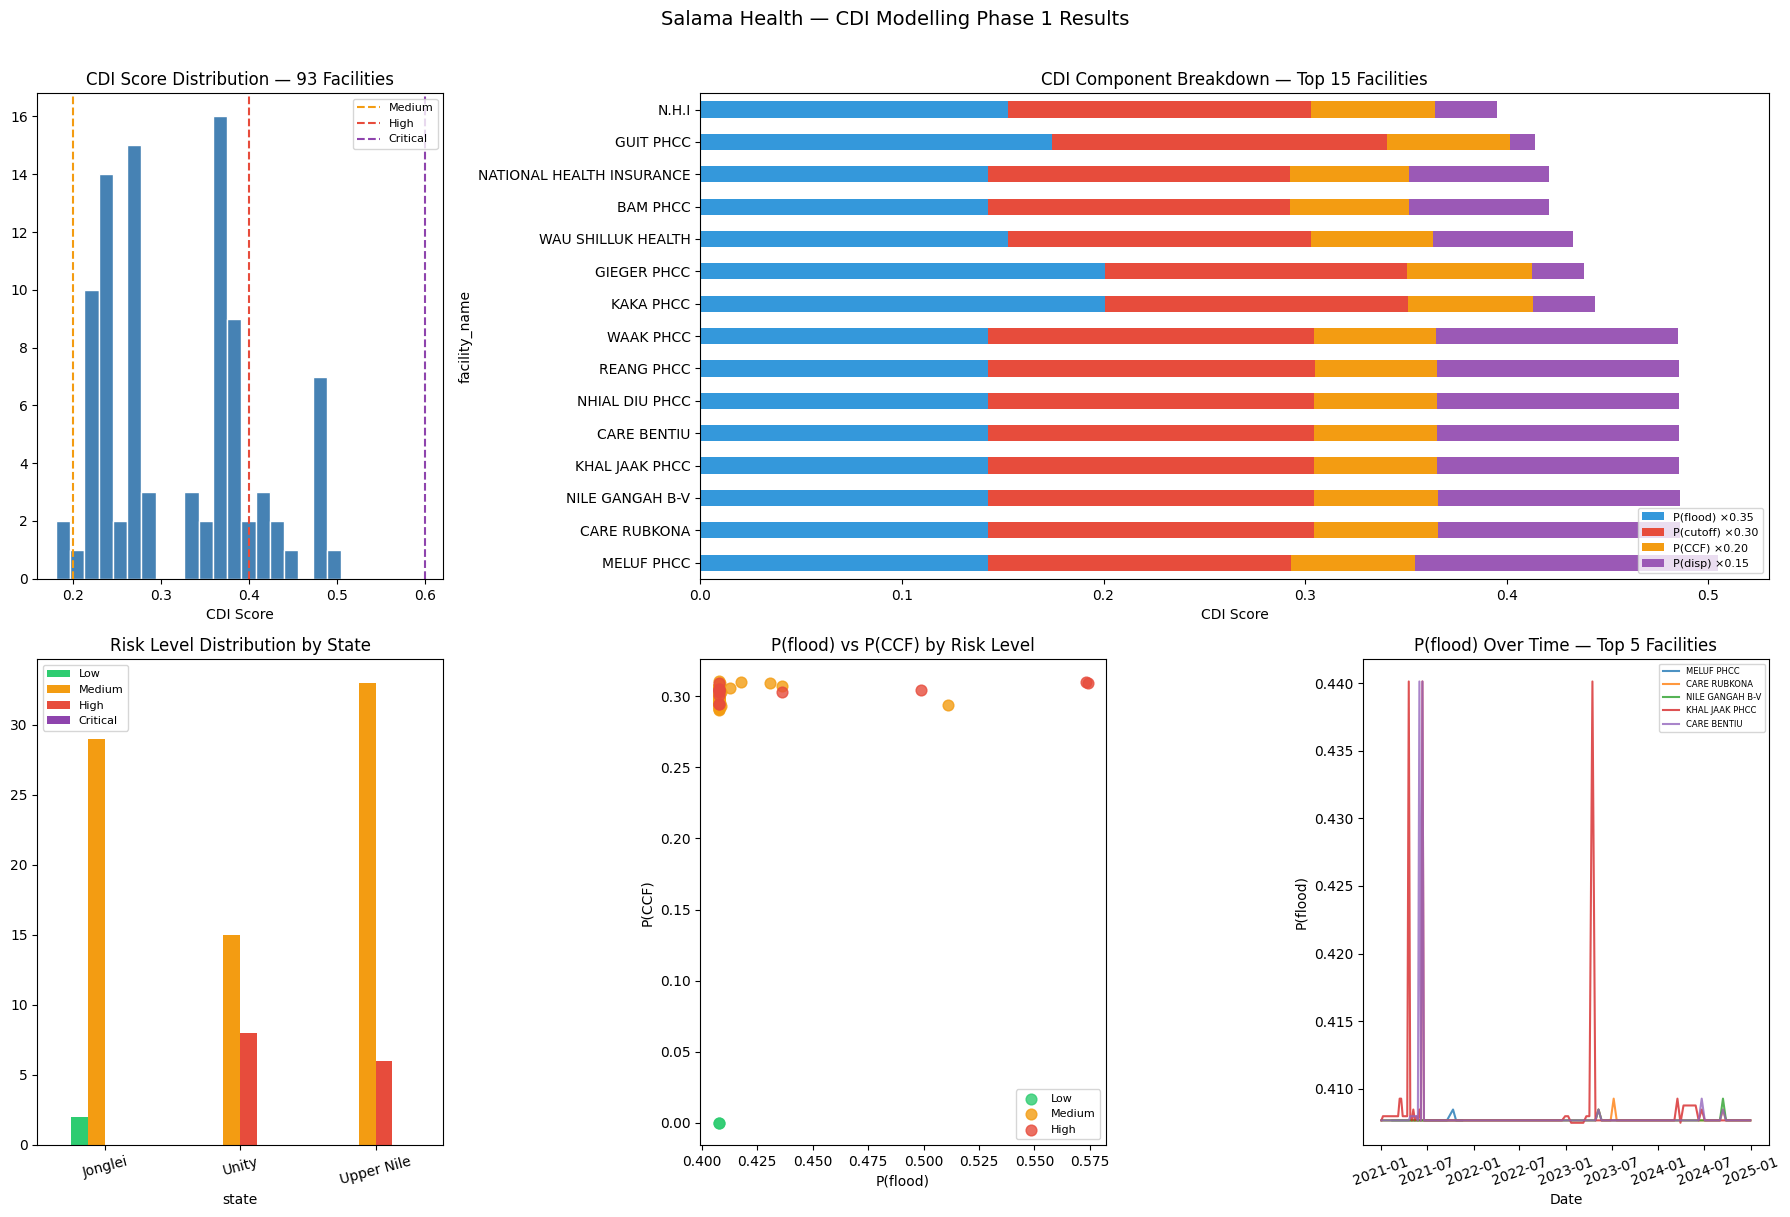

Charts saved


In [11]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

palette = {'Low':'#2ecc71','Medium':'#f39c12','High':'#e74c3c','Critical':'#8e44ad'}

# CDI distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(cdi_scores['CDI'], bins=20, color='steelblue', edgecolor='white')
ax1.axvline(0.20, color='#f39c12', linestyle='--', label='Medium')
ax1.axvline(0.40, color='#e74c3c', linestyle='--', label='High')
ax1.axvline(0.60, color='#8e44ad', linestyle='--', label='Critical')
ax1.set_title('CDI Score Distribution — 93 Facilities')
ax1.set_xlabel('CDI Score')
ax1.legend(fontsize=8)

# CDI components stacked bar — top 15 facilities
ax2 = fig.add_subplot(gs[0, 1:])
top15 = cdi_scores.head(15).set_index('facility_name')
components = pd.DataFrame({
    'P(flood) ×0.35':   top15['P_flood']  * 0.35,
    'P(cutoff) ×0.30':  top15['P_cutoff'] * 0.30,
    'P(CCF) ×0.20':     top15['P_CCF']    * 0.20,
    'P(disp) ×0.15':    top15['P_disp']   * 0.15,
})
components.plot(kind='barh', stacked=True, ax=ax2,
                color=['#3498db','#e74c3c','#f39c12','#9b59b6'])
ax2.set_title('CDI Component Breakdown — Top 15 Facilities')
ax2.set_xlabel('CDI Score')
ax2.legend(loc='lower right', fontsize=8)

# Risk level by state
ax3 = fig.add_subplot(gs[1, 0])
state_risk = cdi_scores.groupby(['state','risk_level']).size().unstack(fill_value=0)
state_risk.plot(kind='bar', ax=ax3,
                color=[palette.get(c,'grey') for c in state_risk.columns])
ax3.set_title('Risk Level Distribution by State')
ax3.tick_params(axis='x', rotation=15)
ax3.legend(fontsize=8)

# P(flood) vs P(CCF) scatter
ax4 = fig.add_subplot(gs[1, 1])
for level, grp in cdi_scores.groupby('risk_level', observed=True):
    ax4.scatter(grp['P_flood'], grp['P_CCF'],
               label=str(level), color=palette.get(str(level),'grey'), s=60, alpha=0.8)
ax4.set_xlabel('P(flood)')
ax4.set_ylabel('P(CCF)')
ax4.set_title('P(flood) vs P(CCF) by Risk Level')
ax4.legend(fontsize=8)

# CDI over time — top 5 facilities
ax5 = fig.add_subplot(gs[1, 2])
top5_names = cdi_scores.head(5)['facility_name'].tolist()
for fname in top5_names:
    fac_data = df[df['facility_name'] == fname].sort_values('date')
    p_flood  = model.predict_proba(fac_data[FEATURE_COLS].fillna(0))[:, 1]
    ax5.plot(fac_data['date'], p_flood,
             label=fname[:20], alpha=0.8, linewidth=1.5)
ax5.set_title('P(flood) Over Time — Top 5 Facilities')
ax5.set_xlabel('Date')
ax5.set_ylabel('P(flood)')
ax5.legend(fontsize=6)
ax5.tick_params(axis='x', rotation=20)

plt.suptitle('Salama Health — CDI Modelling Phase 1 Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/cdi_phase1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Charts saved')

## 10. Save All Outputs

In [12]:
S# Save CDI scores
cdi_scores.to_csv(f'{OUT_DIR}/SSD_CDI_Scores_Phase1.csv', index=False)
print(f'CDI scores saved: {len(cdi_scores)} facilities')

# Save XGBoost model
with open(f'{OUT_DIR}/SSD_XGBoost_Flood_Model.pkl','wb') as f:
    pickle.dump(model, f)
print('XGBoost model saved')

# Save performance metrics
metrics = {
    'auc_roc':         round(auc, 4),
    'f1_score':        round(f1, 4),
    'precision':       round(precision, 4),
    'recall':          round(recall, 4),
    'cv_auc_mean':     round(float(np.mean(cv_auc)), 4),
    'cv_auc_std':      round(float(np.std(cv_auc)),  4),
    'cv_f1_mean':      round(float(np.mean(cv_f1)),  4),
    'cv_f1_std':       round(float(np.std(cv_f1)),   4),
    'train_rows':      len(train),
    'test_rows':       len(test),
    'features':        len(FEATURE_COLS),
    'facilities':      int(df['facility_name'].nunique()),
    'disruption_rate': round(float(df['disrupted'].mean()), 4),
    'scale_pos_weight':round(scale_pos_weight, 1),
}
with open(f'{OUT_DIR}/model_metrics_phase1.json','w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved')

# Print summary
print('\n── Phase 1 Summary ──────────────────────────────────────────────────────')
print(f'AUC-ROC:       {auc:.4f}')
print(f'F1 Score:      {f1:.4f}')
print(f'CV AUC:        {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}')
print(f'Facilities:    {len(cdi_scores)}')
print(f'High risk:     {(cdi_scores["risk_level"] == "High").sum()}')
print(f'Critical risk: {(cdi_scores["risk_level"] == "Critical").sum()}')
print(f'Top facility:  {cdi_scores.iloc[0]["facility_name"]} — CDI {cdi_scores.iloc[0]["CDI"]}')
print(f'\nOutputs saved to: {OUT_DIR}')

CDI scores saved: 93 facilities
XGBoost model saved
Metrics saved

── Phase 1 Summary ──────────────────────────────────────────────────────
AUC-ROC:       0.9996
F1 Score:      0.9864
CV AUC:        1.0000 ± 0.0000
Facilities:    93
High risk:     14
Critical risk: 0
Top facility:  MELUF PHCC — CDI 0.505

Outputs saved to: /kaggle/working
